# HOMEWORK 13

In this homework you are going to build your first classifier for the CIFAR-10 dataset. This dataset contains 10 different classes and you can learn more about it [here](https://www.cs.toronto.edu/~kriz/cifar.html). This homework consists of the following tasks:
* Dataset inspection
* Building the network
* Training
* Evaluation

At the end, as usual, there will be a couple of questions for you to answer :-)

In [38]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Dense, Flatten, Input, MaxPooling2D
from tensorflow.keras import Model
from time import time

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

# Set the seeds for reproducibility
from numpy.random import seed
from tensorflow.random import set_seed
seed_value = 1234578790
seed(seed_value)
set_seed(seed_value)

### Step 0: Dataset Inspection

Load the dataset and make a quick inspection.

/tmp/ipython-input-3329862148.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(classes[int(y_train[idx])])


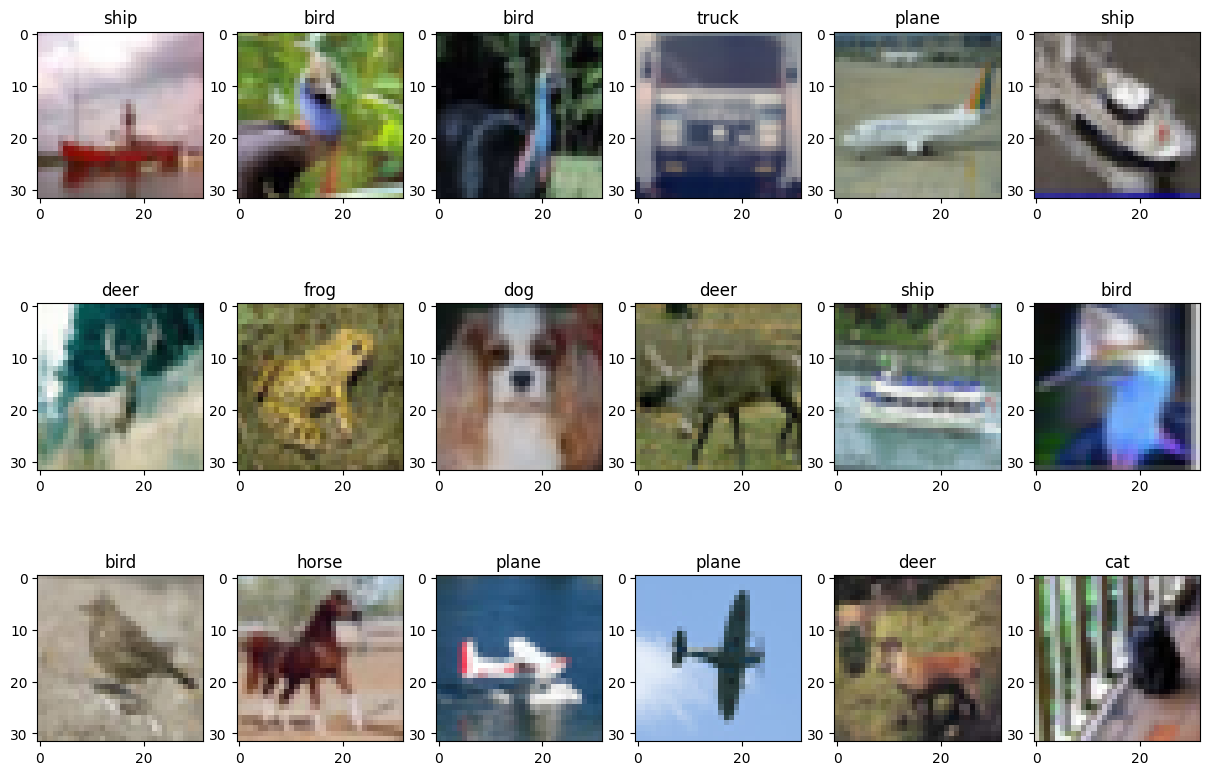

In [39]:
import random

# Load the dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
# Mapping from class ID to class name
classes = {0:'plane', 1:'car', 2:'bird', 3:'cat', 4:'deer',
           5:'dog', 6:'frog', 7:'horse', 8:'ship', 9:'truck'}

# Dataset params
num_classes = len(classes)
size = x_train.shape[1]

# Visualize random samples (as a plot with 3x6 samples)
for ii in range(18):
    plt.subplot(3,6,ii+1)
    # Pick a random sample
    dataset_size = x_train.shape[0]
    idx = random.randint(0, dataset_size)
    img_x = x_train[idx]
    label_x = y_train[idx]
    # Show the image and the label
    plt.imshow(img_x)
    plt.title(classes[int(y_train[idx])])

Compute the class histogram (you can visualize it if you want). Is the dataset balanced?

Hint: You might find [Counter](https://docs.python.org/3/library/collections.html#collections.Counter) tool useful. In any case, it's up to you how you compute the histogram.

(Text(0.5, 0, 'Classes'), Text(0, 0.5, 'Counts'))

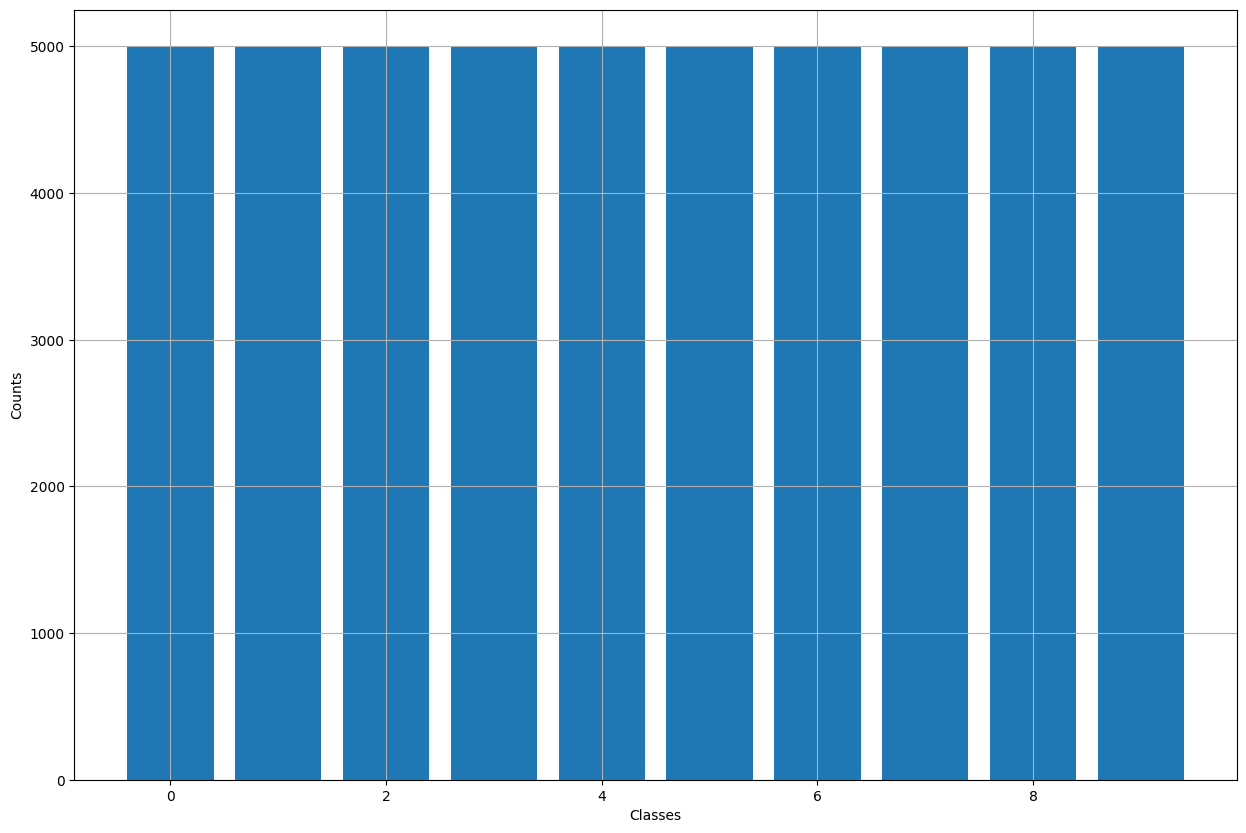

In [40]:
# Compute the class histogram
from collections import Counter
hist=Counter(y_train.flatten())

plt.bar(hist.keys(), hist.values()), plt.grid(True)
plt.xlabel('Classes'), plt.ylabel('Counts')

**From student**: this dataset is pretty balanced since there is equal amount of entries for every class.

### Step 1: Data Preparation

In this step, you'll need to prepare the data for training, i.e., you will have to normalize it and encode the labels as one-hot vectors.

In [41]:
# Normalization
x_train = x_train / 255
x_test = x_test / 255

# One-hot encoding
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test = tf.keras.utils.to_categorical(y_test, num_classes)

print('Train set:   ', len(y_train), 'samples')
print('Test set:    ', len(y_test), 'samples')
print('Sample dims: ', x_train.shape)

Train set:    50000 samples
Test set:     10000 samples
Sample dims:  (50000, 32, 32, 3)


### Step 2: Building the Classifier

Build the CNN for CIFAR10 classification. For starters, you can use the same network we used in the lesson for the MNIST problem.

In [46]:
# Build the classifier
inputs = Input(shape=(size, size, 3))

net = Conv2D(16, kernel_size=(3, 3), activation="relu")(inputs)
net = MaxPooling2D(pool_size=(2, 2))(net)
net = Conv2D(32, kernel_size=(3, 3), activation="relu")(net)
net = MaxPooling2D(pool_size=(2, 2))(net)
net = Flatten()(net)
outputs = Dense(num_classes, activation="softmax")(net)

model = Model(inputs, outputs)

# Show the model
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 13, 13, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        11,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,618 (64.91 KB)

 Trainable params: 16,618 (64.91 KB)

 Non-trainable params: 0 (0.00 B)

### Step 3: Training

Compile the model and train it.

In [47]:
epochs = 25
batch_size = 128

# Compile the model
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

# Train the model
history = model.fit(x_train, y_train, batch_size, epochs, validation_split=0.1)

Epoch 1/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 17s 46ms/step - accuracy: 0.3148 - loss: 1.9008 - val_accuracy: 0.4606 - val_loss: 1.5400
Epoch 2/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - accuracy: 0.4884 - loss: 1.4481 - val_accuracy: 0.5040 - val_loss: 1.4145
Epoch 3/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 16s 45ms/step - accuracy: 0.5326 - loss: 1.3355 - val_accuracy: 0.5464 - val_loss: 1.2887
Epoch 4/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 20s 44ms/step - accuracy: 0.5628 - loss: 1.2547 - val_accuracy: 0.5790 - val_loss: 1.2039
Epoch 5/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.5875 - loss: 1.1911 - val_accuracy: 0.5988 - val_loss: 1.1508
Epoch 6/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 16s 46ms/step - accuracy: 0.6027 - loss: 1.1430 - val_accuracy: 0.6082 - val_loss: 1.1132
Epoch 7/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 16s 45ms/step - accuracy: 0.6153 - loss: 1.1054 - val_accuracy: 0.6216 - val_loss: 1.0815
Epoch 8/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - accuracy: 0.6258 - loss: 1.0739 - 

Train Acc      0.7139333486557007
Validation Acc 0.6787999868392944


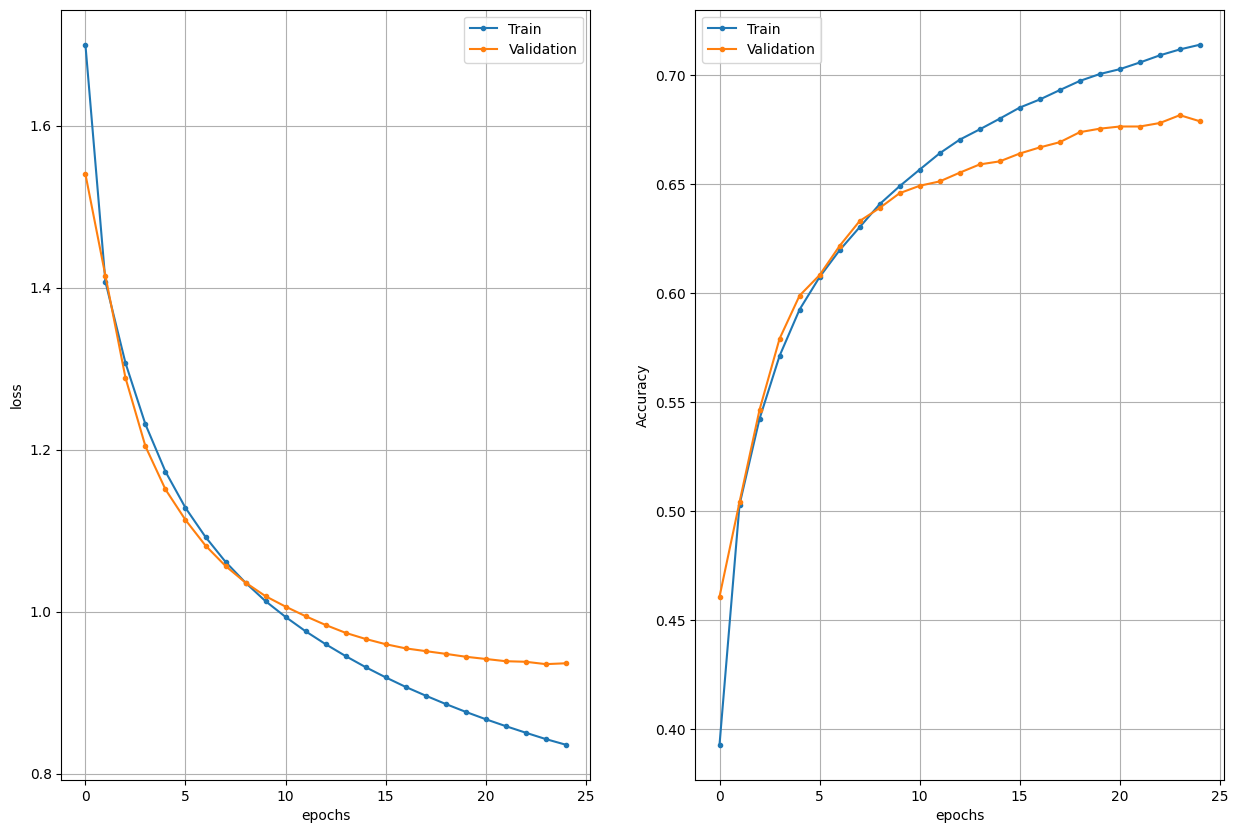

In [48]:
# Show training history (this cell is complete, nothing to implement here :-) )
h = history.history
epochs = range(len(h['loss']))

plt.subplot(121), plt.plot(epochs, h['loss'], '.-', epochs, h['val_loss'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('loss')
plt.legend(['Train', 'Validation'])
plt.subplot(122), plt.plot(epochs, h['accuracy'], '.-',
                           epochs, h['val_accuracy'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

print('Train Acc     ', h['accuracy'][-1])
print('Validation Acc', h['val_accuracy'][-1])

### Step 4: Evaluation

In this step, you have to calculate the accuracies and visualize some random samples. For the evaluation, you are going to use the test split from the dataset.

In [65]:
# Compute the labels and the predictions as sparse values
y_true = np.argmax(y_test, axis=1)
y_pred = model.predict(x_test)
y_pred = np.argmax(y_pred, axis=1)

idx = random.sample(range(len(y_test)), 5)
print('True', y_true[idx])
print('Pred', y_pred[idx])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
True [7 8 9 7 2]
Pred [7 0 9 7 5]


In [69]:
# Compute and print the accuracy for each class
for class_id, class_name in classes.items():
    mask = y_true == class_id
    # first get all predictions for this class
    all_predictions = y_pred[mask]
    # get correct predictions by filtering only correct preds
    correct_predictions = all_predictions[all_predictions==class_id]
    # calculate accuracy by dividing number of correct_prediction by general class entries
    acc = len(correct_predictions) / len(all_predictions)
    print(class_name, acc)

plane 0.733
car 0.805
bird 0.56
cat 0.438
deer 0.666
dog 0.503
frog 0.751
horse 0.72
ship 0.731
truck 0.772


In [70]:
# Print the overall stats
ev = model.evaluate(x_test, y_test)
print('Test loss  ', ev[0])
print('Test metric', ev[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6714 - loss: 0.9628
Test loss   0.9739130139350891
Test metric 0.667900025844574


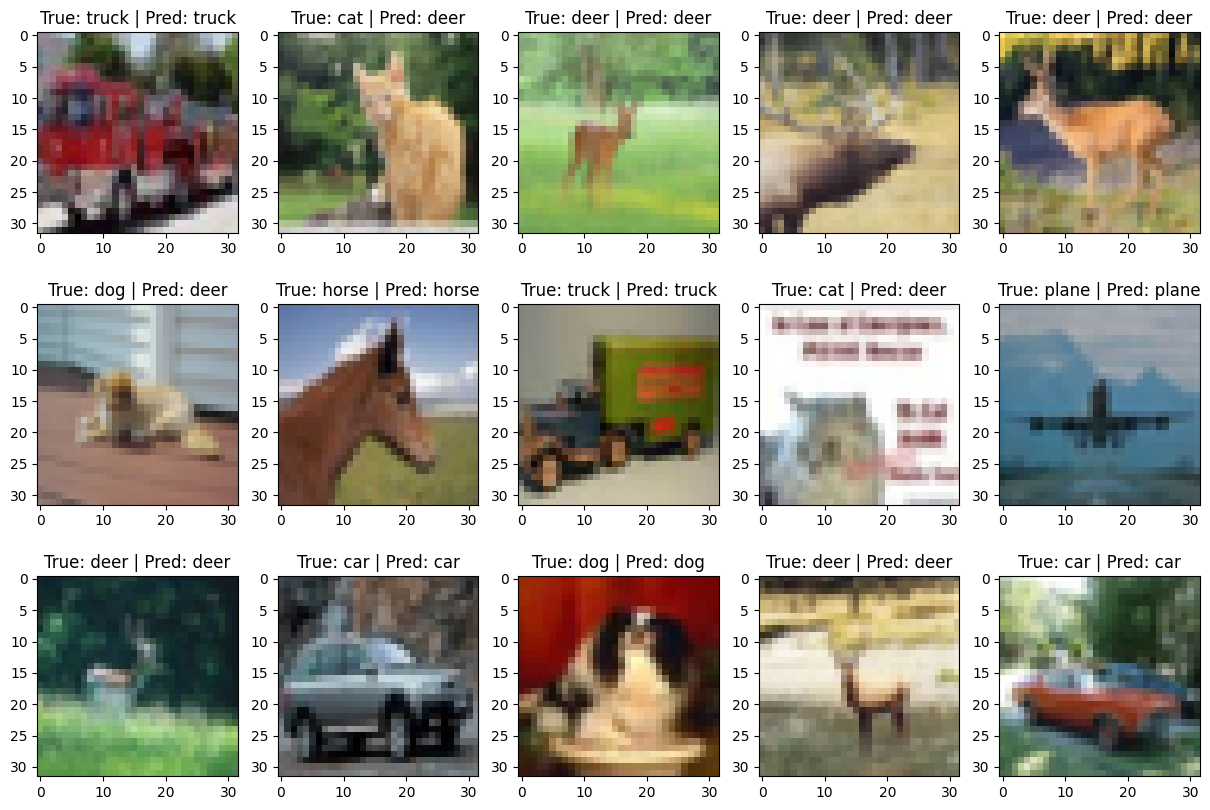

In [72]:
# Show random samples
for ii in range(15):
    # Pick a random sample
    idx = random.randint(0, len(x_test))
    # Show the results
    plt.subplot(3,5,ii+1), plt.imshow(x_test[idx, ...])
    plt.title('True: ' + str(classes[y_true[idx]]) + ' | Pred: ' + str(classes[y_pred[idx]]))

### Questions
* What is the overall accuracy of the classifier?

  **Answer**: The accuracy is around 0.7. It's better then random guessing but still far from ideal.

* What modifications would you do in order to improve the classification accuracy?

  **Answer**: I think that turning images to grayscale would make it more robust to colors. For example, some cats have the same color as deer so they were falsely classified as deer. Also, since those images have a lot of features, the max pooling layer at the beggining could filter important feature signals from overall noise.

* Make **one** modification (that you think can help) and train the classifier again. Does the accuracy improve?

  **Answer**: I would try additional max pooling layer.

Epoch 1/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.2294 - loss: 2.1081 - val_accuracy: 0.3566 - val_loss: 1.7594
Epoch 2/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.3802 - loss: 1.7261 - val_accuracy: 0.4000 - val_loss: 1.6311
Epoch 3/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.4184 - loss: 1.6213 - val_accuracy: 0.4278 - val_loss: 1.5650
Epoch 4/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.4417 - loss: 1.5612 - val_accuracy: 0.4498 - val_loss: 1.5226
Epoch 5/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.4604 - loss: 1.5167 - val_accuracy: 0.4610 - val_loss: 1.4881
Epoch 6/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.4743 - loss: 1.4809 - val_accuracy: 0.4778 - val_loss: 1.4573
Epoch 7/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.4881 - loss: 1.4504 - val_accuracy: 0.4938 - val_loss: 1.4331
Epoch 8/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.4996 - loss: 1.4250 - val_accu

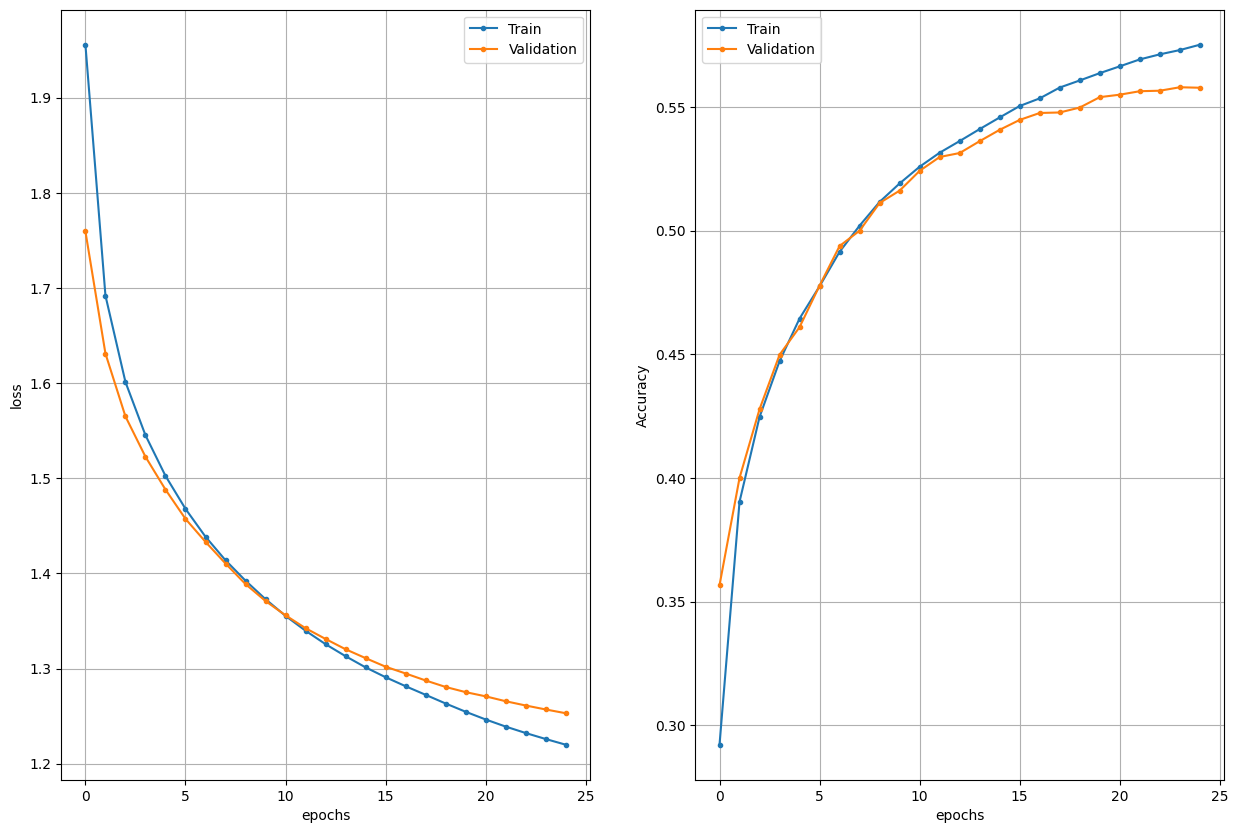

In [80]:
inputs = Input(shape=(size, size, 3))

net = MaxPooling2D(pool_size=(2, 2))(inputs) # <-- new layer here
net = Conv2D(16, kernel_size=(3, 3), activation="relu")(net)
net = MaxPooling2D(pool_size=(2, 2))(net)
net = Conv2D(32, kernel_size=(3, 3), activation="relu")(net)
net = MaxPooling2D(pool_size=(2, 2))(net)
net = Flatten()(net)
outputs = Dense(num_classes, activation="softmax")(net)

model = Model(inputs, outputs)

epochs = 25
batch_size = 128

model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
history = model.fit(x_train, y_train, batch_size, epochs, validation_split=0.1)

h = history.history
epochs = range(len(h['loss']))

plt.subplot(121), plt.plot(epochs, h['loss'], '.-', epochs, h['val_loss'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('loss')
plt.legend(['Train', 'Validation'])
plt.subplot(122), plt.plot(epochs, h['accuracy'], '.-',
                           epochs, h['val_accuracy'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

print('Train Acc     ', h['accuracy'][-1])
print('Validation Acc', h['val_accuracy'][-1])

The accuracy is decreased.